#What percentage of orders are delivered on time, early, or late, and how has this ratio changed over time?

loading the neccessary libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

loading the data

In [34]:
orders=pd.read_parquet('orders.parquet')

In [35]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


delivery delay days

In [36]:
orders['delivery_delay_days']=(orders['order_delivered_customer_date']-orders['order_estimated_delivery_date']).dt.days

using only delivered orders

In [37]:
orders=orders[orders['order_status']=='delivered'].copy()

In [38]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0


delivery buckets

In [40]:
orders['delivery_buckets'] = orders['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else ('Early' if x < 0 else 'On Time')
)

In [41]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,delivery_buckets
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,Early
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,Early
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,Early
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,Early
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,Early


In [42]:
orders_by_bucket_percentage=orders['delivery_buckets'].value_counts(normalize=True).reset_index()

In [43]:
orders_by_bucket_percentage

,delivery_buckets,proportion
0,Early,0.918800
1,Late,0.067725
2,On Time,0.013475


<Axes: xlabel='delivery_buckets'>

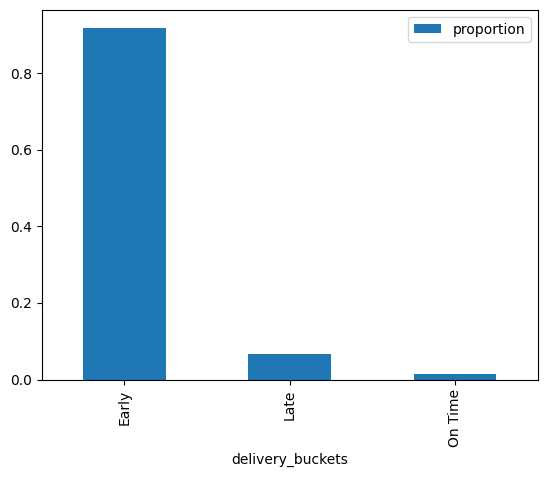

In [44]:
orders_by_bucket_percentage.plot(kind='bar',x='delivery_buckets',y='proportion')

92 % were early
6.7 % were late
1.3% were on time

## showing overtime change

In [45]:
orders['month_year']=orders['order_purchase_timestamp'].dt.to_period('M')

In [46]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,delivery_buckets,month_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,Early,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,Early,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,Early,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,Early,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,Early,2018-02


In [47]:
order_aggregated_on_delivery_buckets=orders.groupby(['delivery_buckets','month_year']).count()['order_id'].reset_index()

In [48]:
order_aggregated_on_delivery_buckets

,delivery_buckets,month_year,order_id
0,Early,2016-10,262
1,Early,2016-12,1
2,Early,2017-01,727
3,Early,2017-02,1600
4,Early,2017-03,2404
...,...,...,...
60,On Time,2018-04,55
61,On Time,2018-05,113
62,On Time,2018-06,15
63,On Time,2018-07,71


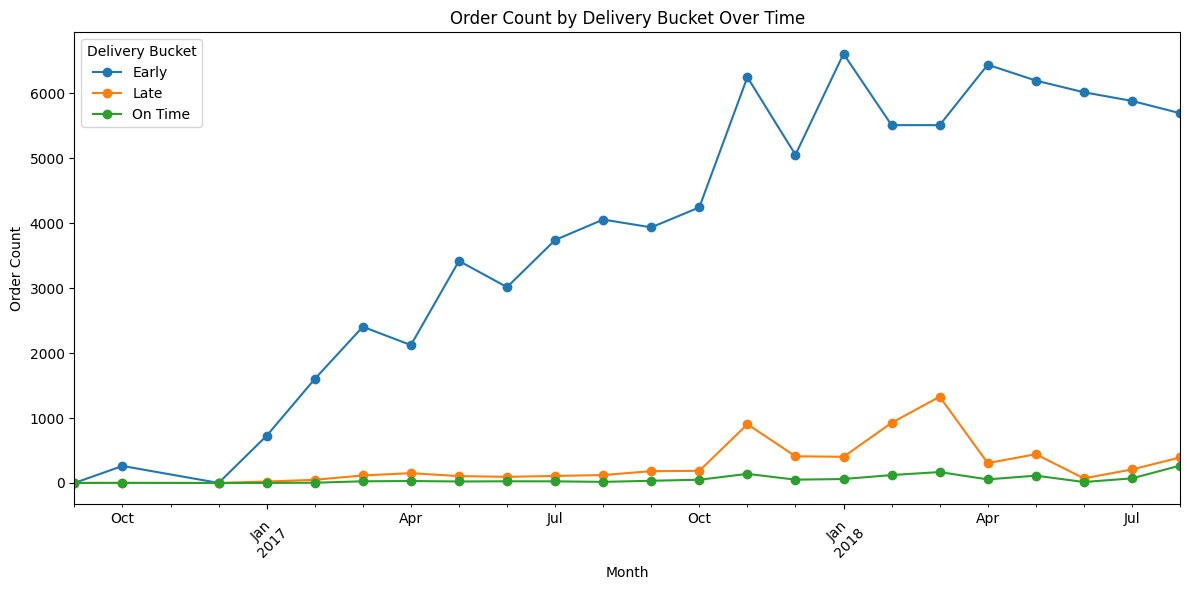

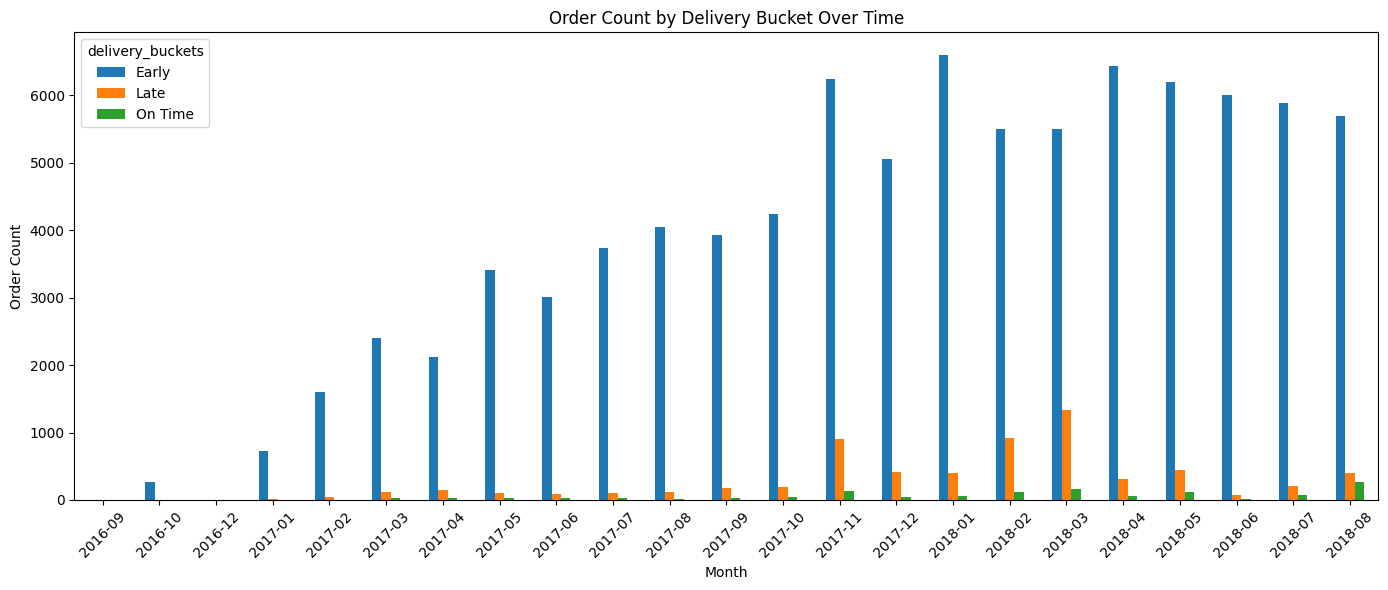

In [50]:
pivot_df = order_aggregated_on_delivery_buckets.pivot(index='month_year', columns='delivery_buckets', values='order_id')
pivot_df = pivot_df.fillna(0)
fig, ax = plt.subplots(figsize=(12, 6))
pivot_df.plot(ax=ax, marker='o')

ax.set_title('Order Count by Delivery Bucket Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Order Count')
ax.legend(title='Delivery Bucket')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(14, 6))
pivot_df.plot(kind='bar', ax=ax, stacked=False)

ax.set_title('Order Count by Delivery Bucket Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Order Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The "Early" bucket dominates throughout the period and scales with overall order
volume growth (low hundreds per month in late 2016 to 5,000-6,500/month by 2018).
"Late" orders stay a thin band through most of 2017 but visibly spike between
November 2017 and February 2018, peaking around 1,300 orders in February 2018,
before falling back to earlier levels by mid-2018 — this spike likely coincides
with Brazil's holiday shopping season (Black Friday, Christmas) straining delivery
capacity. "On Time" remains the smallest bucket throughout, rarely separating
visibly from the x-axis on this raw-count scale.

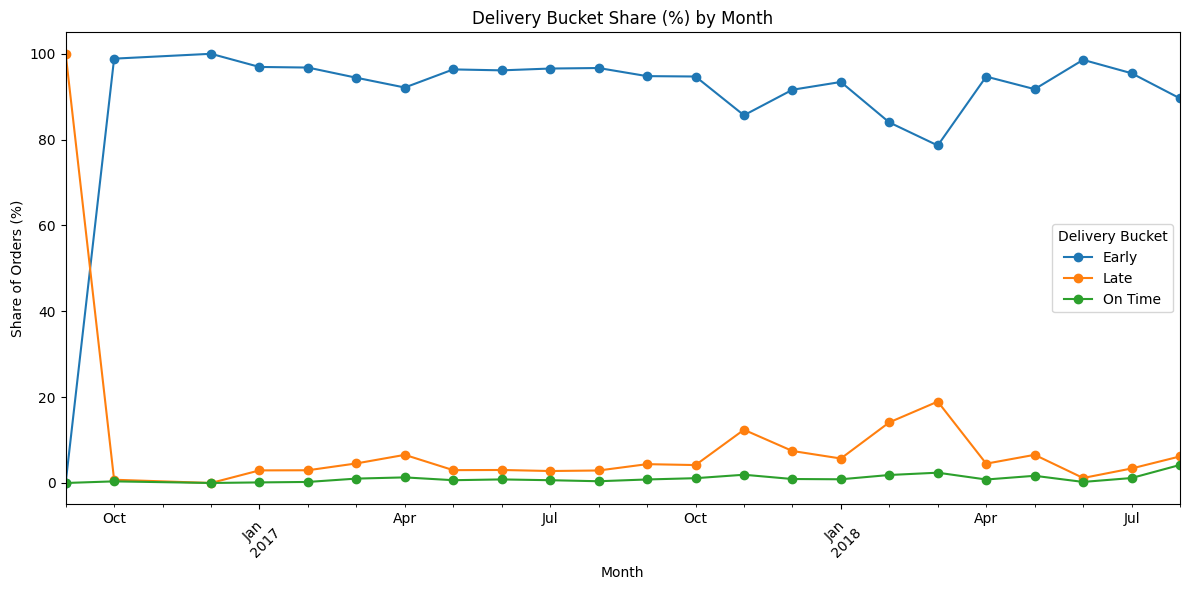

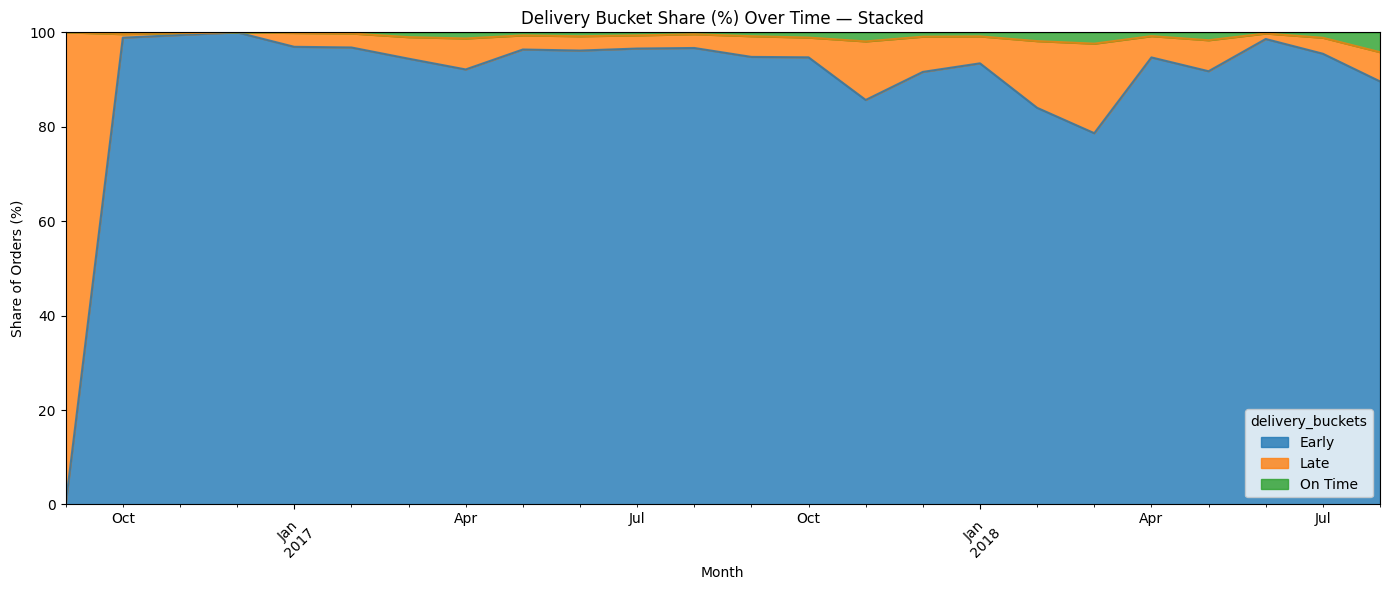

In [51]:

pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
pivot_pct.plot(ax=ax, marker='o')

ax.set_title('Delivery Bucket Share (%) by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Share of Orders (%)')
ax.legend(title='Delivery Bucket')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
pivot_pct.plot(kind='area', stacked=True, ax=ax, alpha=0.8)

ax.set_title('Delivery Bucket Share (%) Over Time — Stacked')
ax.set_xlabel('Month')
ax.set_ylabel('Share of Orders (%)')
ax.set_ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()